I am only cleaning and discovering data because I am going to analyis it using PowerBI

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/amritanshukush/adverse-drug-reaction-adr-reporting/synthetic_drug_data.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/amritanshukush/adverse-drug-reaction-adr-reporting/synthetic_drug_data.csv")
df.head()

,ReportID,PatientAge,Gender,DrugName,Dosage,DurationDays,ConcomitantDrugs,ADR_Code,Seriousness,OnsetDays
0,REP-VJpHH7RG,52,Other,Ibuprofen,658mg,31,"Simvastatin, Fluoxetine, Gabapentin",10016256,mild,12
1,REP-xZHEIV6F,64,Male,Atorvastatin,359mg,33,NaN,10019211,mild,5
2,REP-j2PXcrTb,45,Female,Amoxicillin,179mg,28,NaN,10016256,mild,3
3,REP-vzYm2NEH,72,Female,Prednisone,46mg,29,"Metformin, Lisinopril",10013968,mild,6
4,REP-WWcINmT6,56,Male,Atorvastatin,936mg,28,NaN,10037660,mild,9


In [3]:
df.size

10000000

In [4]:
df.dtypes

ReportID            object
PatientAge           int64
Gender              object
DrugName            object
Dosage              object
DurationDays         int64
ConcomitantDrugs    object
ADR_Code             int64
Seriousness         object
OnsetDays            int64
dtype: object

#  Converting the dosage to a numeric data 

In [5]:
df['Dosage'] = df['Dosage'].str.replace('mg', '')

 #Convert the column type from string (object) to integer
df['Dosage'] = df['Dosage'].astype(int)

 #Rename the column to include the unit
df = df.rename(columns={'Dosage': 'Dosage_mg'})

# Missing Data

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

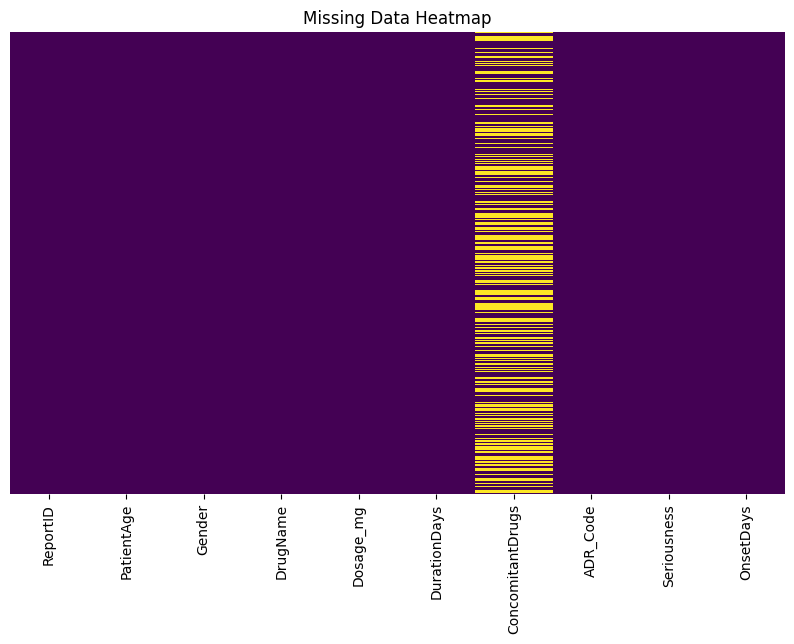

In [7]:
plt.figure(figsize=(10, 6))

sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

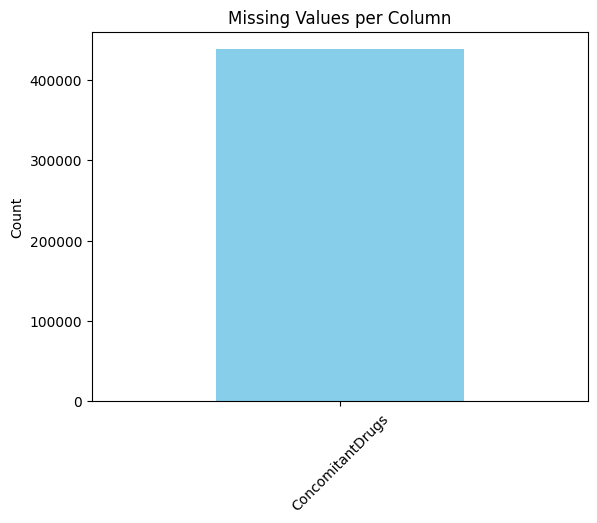

In [8]:
null_counts = df.isnull().sum()
null_counts[null_counts > 0].plot(kind='bar', color='skyblue')
plt.title('Missing Values per Column')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [9]:
# Calculate the percentage of missing values
missing_percentage = df['ConcomitantDrugs'].isnull().mean() * 100

print(f"Percentage of missing data in ConcomitantDrugs: {missing_percentage}%")

Percentage of missing data in ConcomitantDrugs: 43.7828%


In [10]:
df['ConcomitantDrugs'] = df['ConcomitantDrugs'].fillna('none')

#  Outliers 

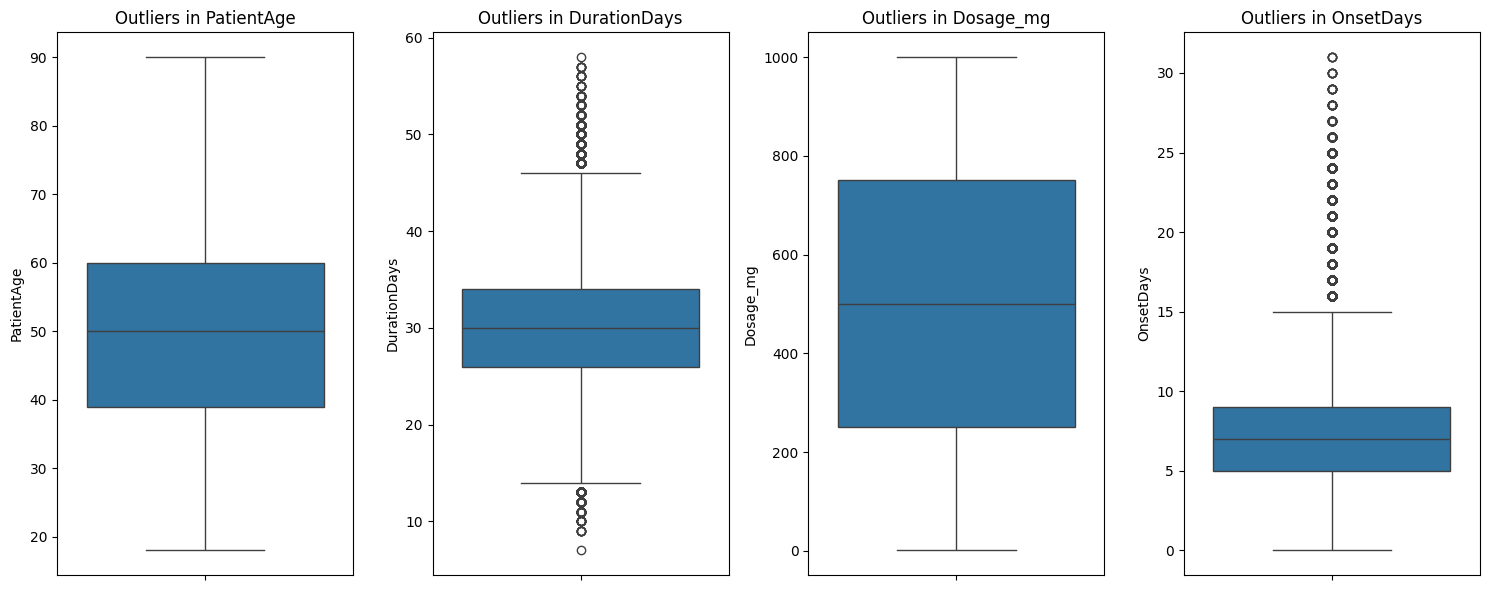

In [11]:

cols = ['PatientAge', 'DurationDays', 'Dosage_mg','OnsetDays']


plt.figure(figsize=(15, 6))

for i, col in enumerate(cols):
    plt.subplot(1, 4, i + 1)
    
    sns.boxplot(y=df[col])
    #sns.stripplot(y=df[col], color='red', alpha=0.5) 
    plt.title(f'Outliers in {col}')

plt.tight_layout()
plt.show()

As we can see the outliers in duration days , which may mean that it is rare for the patients to experiance reactions in short or long time intervals; so this doesn't mean we have to exclude them from our data 


and the same thing goes to the onset days

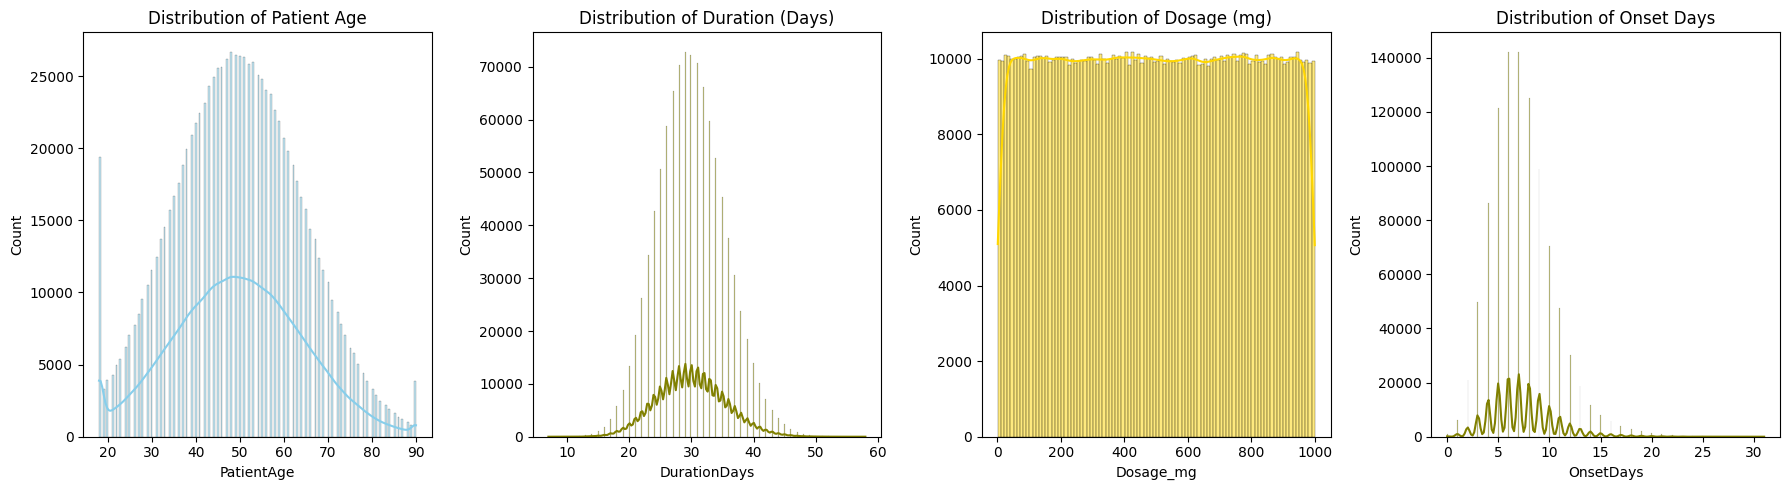

In [12]:
# 3. Create a layout for 3 plots side-by-side
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# Plot PatientAge Distribution
sns.histplot(df['PatientAge'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribution of Patient Age')

# Plot DurationDays Distribution
sns.histplot(df['DurationDays'], kde=True, color='olive', ax=axes[1])
axes[1].set_title('Distribution of Duration (Days)')

# Plot Dosage_mg Distribution
sns.histplot(df['Dosage_mg'], kde=True, color='gold', ax=axes[2])
axes[2].set_title('Distribution of Dosage (mg)')

sns.histplot(df['OnsetDays'], kde=True, color='olive', ax=axes[3])
axes[3].set_title('Distribution of Onset Days')


plt.tight_layout()
plt.show()

As we can see the dosage isn't a normal distribution 

also we can see a skewness in the onset distribution 

In [13]:
print(df['Dosage_mg'].describe())

count    1000000.000000
mean         500.396800
std          288.690515
min            1.000000
25%          250.000000
50%          500.000000
75%          751.000000
max         1000.000000
Name: Dosage_mg, dtype: float64


According to the stats for the dosage we can confirm it is actuelly a uniform data 

$$\mu = \frac{a + b}{2}$$


$$\sigma = \sqrt{\frac{(b - a)^2}{12}}$$

In [14]:
df = df.drop(columns = 'ReportID')

In [15]:
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype('category').cat.codes

full_corr = df.corr()
print(full_corr)

                  PatientAge    Gender  DrugName  Dosage_mg  DurationDays  \
PatientAge          1.000000  0.000213 -0.000414  -0.002257      0.000220   
Gender              0.000213  1.000000 -0.000418   0.001249     -0.001367   
DrugName           -0.000414 -0.000418  1.000000  -0.000522      0.000037   
Dosage_mg          -0.002257  0.001249 -0.000522   1.000000      0.001706   
DurationDays        0.000220 -0.001367  0.000037   0.001706      1.000000   
ConcomitantDrugs    0.001646  0.001348 -0.000874  -0.000751      0.001219   
ADR_Code            0.001277 -0.000374  0.000228   0.001863     -0.000262   
Seriousness        -0.000061 -0.000405  0.000937   0.000863      0.001042   
OnsetDays          -0.000587 -0.000398  0.000362  -0.000605      0.000848   

                  ConcomitantDrugs  ADR_Code  Seriousness  OnsetDays  
PatientAge                0.001646  0.001277    -0.000061  -0.000587  
Gender                    0.001348 -0.000374    -0.000405  -0.000398  
DrugName        

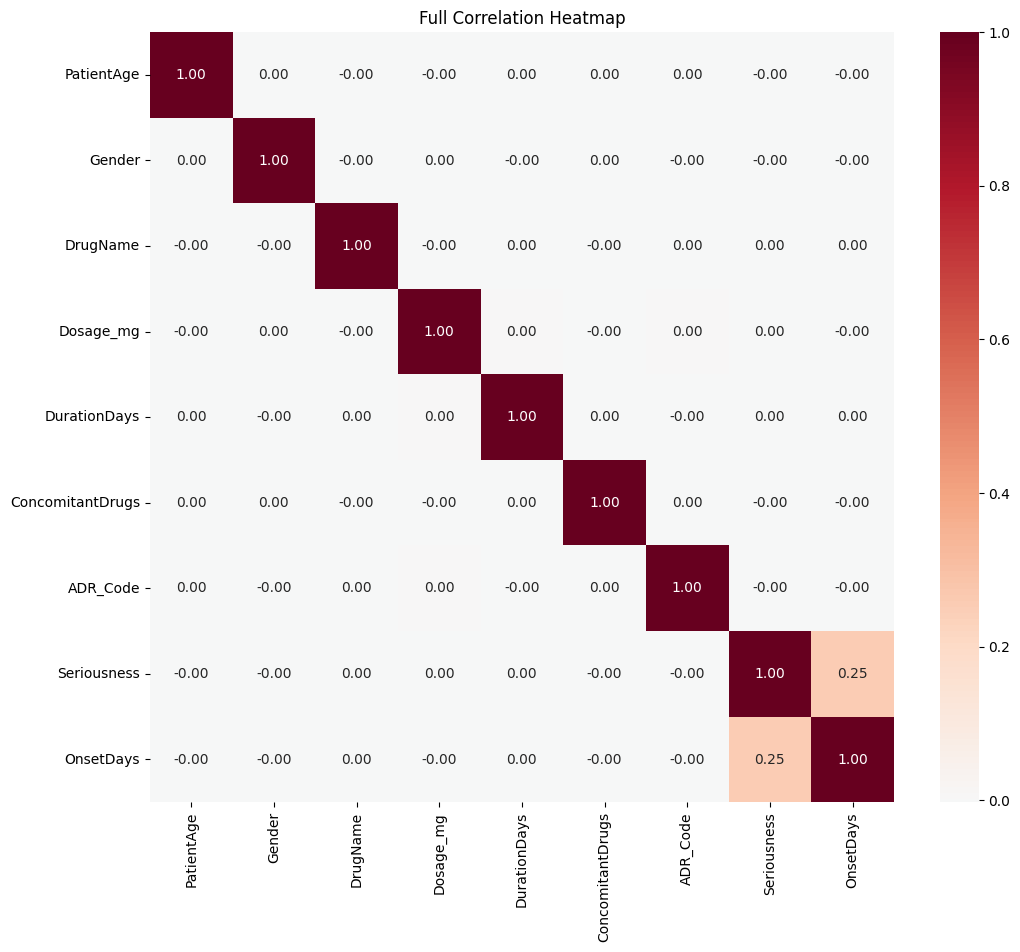

In [16]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), 
            annot=True,       
            cmap='RdBu_r',   
            center=0,         
            fmt=".2f")       

plt.title('Full Correlation Heatmap')
plt.show()

as we can see , all the columns are independent except for seriusness and onsetdays which has a weak relationship

In [17]:
unique_count = df['ADR_Code'].nunique()

unique_values = df['ADR_Code'].unique()

print(f"Number of unique ADR codes: {unique_count}")
print(f"List of unique ADR codes: {unique_values}")

Number of unique ADR codes: 12
List of unique ADR codes: [10016256 10019211 10013968 10037660 10012735 10021097 10013573 10028813
 10000081 10002198 10037844 10047700]


In [18]:
unique_count = df['DrugName'].nunique()

unique_values = df['DrugName'].unique()

print(f"Number of unique DrugNames: {unique_count}")
print(f"List of unique DrugNames: {unique_values}")

Number of unique DrugNames: 20
List of unique DrugNames: [ 9  4  2 16 11  0 18 15 17 14  8  3  1 10  5 13 19  6  7 12]


Text(0.5, 1.0, 'Network Analysis: Drug Name to ADR Code Associations')

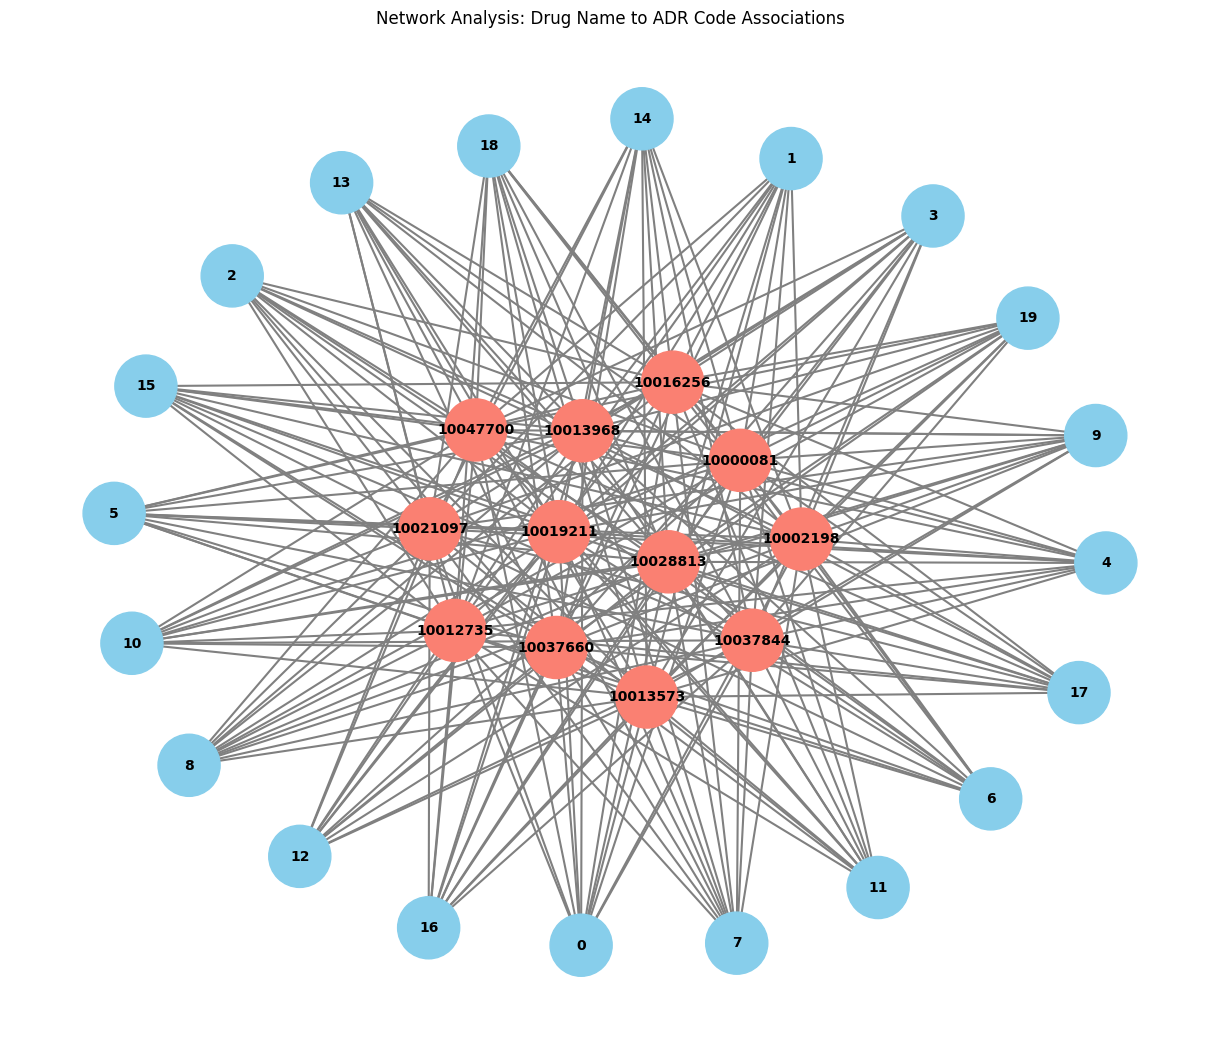

In [19]:
G = nx.Graph()


for index, row in df.iterrows():
    G.add_node(row['DrugName'], type='Drug')
    G.add_node(str(row['ADR_Code']), type='ADR') 
    
 
    G.add_edge(row['DrugName'], str(row['ADR_Code']))

pos = nx.spring_layout(G, k=0.5)



node_colors = []
for node, data in G.nodes(data=True):
    if data['type'] == 'Drug':
        node_colors.append('skyblue') # Drugs are blue
    else:
        node_colors.append('salmon')   # ADRs are red


plt.figure(figsize=(12, 10))
nx.draw(G, pos, 
        with_labels=True,      
        node_color=node_colors, 
        node_size=2000,        
        font_size=10, 
        font_weight='bold',
        edge_color='gray',     
        width=1.5)            

plt.title('Network Analysis: Drug Name to ADR Code Associations')
# plt.show()

In [22]:
df["Seriousness"].unique()

array([1, 3, 2, 0], dtype=int8)

# ANOVA TEST

In [29]:
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

import statsmodels.api as sm
from statsmodels.formula.api import ols

In [24]:
cols_to_test = ['PatientAge', 'DurationDays', 'Dosage_mg', 'OnsetDays']

print(f"{'Variable':<15} | {'F-Statistic':<12} | {'p-value':<12} | {'Result'}")
print("-" * 60)

for col in cols_to_test:
    # We group the data by Seriousness and extract the target column for each group
    # This creates 4 lists of values (one for 0, 1, 2, and 3)
    group_data = [df[df['Seriousness'] == level][col] for level in sorted(df['Seriousness'].unique())]
    
    # Run the One-Way ANOVA
    f_stat, p_val = stats.f_oneway(*group_data)
    
    # Determine significance
    sig = "Significant" if p_val < 0.05 else "Not Significant"
    
    print(f"{col:<15} | {f_stat:<12.2f} | {p_val:<12.4e} | {sig}")

Variable        | F-Statistic  | p-value      | Result
------------------------------------------------------------
PatientAge      | 0.14         | 9.3338e-01   | Not Significant
DurationDays    | 0.51         | 6.7808e-01   | Not Significant
Dosage_mg       | 2.67         | 4.5753e-02   | Significant
OnsetDays       | 105496.13    | 0.0000e+00   | Significant


In [28]:
formula = 'Seriousness ~ C(Gender) + Dosage_mg + C(Gender):Dosage_mg'

model = ols(formula, data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                            sum_sq        df         F    PR(>F)
C(Gender)                 0.190717       2.0  0.351381  0.703716
Dosage_mg                 0.202093       1.0  0.744680  0.388166
C(Gender):Dosage_mg       0.032323       2.0  0.059553  0.942186
Residual             271380.958625  999994.0       NaN       NaN


In [30]:
formula = 'Seriousness ~ C(Gender) * C(DrugName) * Dosage_mg'

model = ols(formula, data=df).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

print("--- Three-Way ANOVA Results ---")
print(anova_table)

--- Three-Way ANOVA Results ---
                                        sum_sq        df         F    PR(>F)
C(Gender)                             0.192130       2.0  0.353989  0.701883
C(DrugName)                           9.114870      19.0  1.767754  0.020548
C(Gender):C(DrugName)                 8.753487      38.0  0.848834  0.731652
Dosage_mg                             0.204494       1.0  0.753539  0.385358
C(Gender):Dosage_mg                   0.029467       2.0  0.054292  0.947156
C(DrugName):Dosage_mg                 4.022218      19.0  0.780076  0.733875
C(Gender):C(DrugName):Dosage_mg      13.417931      38.0  1.301149  0.101175
Residual                         271345.644466  999880.0       NaN       NaN


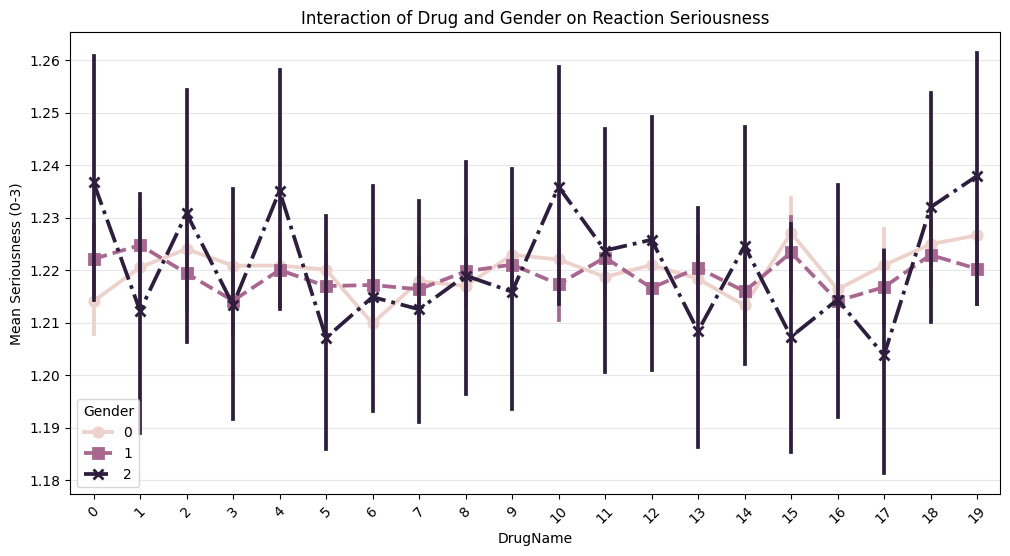

In [31]:
plt.figure(figsize=(12, 6))

sns.pointplot(data=df, x='DrugName', y='Seriousness', hue='Gender', 
              markers=["o", "s", "x"], linestyles=["-", "--", "-."])

plt.title('Interaction of Drug and Gender on Reaction Seriousness')
plt.ylabel('Mean Seriousness (0-3)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()